# Chapter 1 · Bocklandt et al. 2011 — *Epigenetic Predictor of Age*
## Part 1 of 3: The data, its structure, and quality control

> Bocklandt S, Lin W, Sehl ME, Sánchez FJ, Sinsheimer JS, **Horvath S**, Vilain E (2011).
> Epigenetic Predictor of Age. *PLoS ONE* 6(6): e14821.
> [doi:10.1371/journal.pone.0014821](https://doi.org/10.1371/journal.pone.0014821)

This is one of the first papers to **predict a person's age from DNA methylation**. The authors measured methylation at about 27,000 sites in saliva from identical twins. They found sites whose methylation changes steadily with age and built a regression model from just two of them. It is small, simple and open, which makes it a good place to start. Steve Horvath is a co-author, and several ideas here (network modules, penalized regression, leave-one-out validation) return two years later in his famous pan-tissue clock.

**The chapter has three parts:**

| Part | Language | Question |
|---|---|---|
| **1. Data & QC** (this notebook) | Python | What exactly is in the public dataset, and is it clean? |
| 2. Age-associated CpGs & modules | R | Which CpG sites change with age? Can we reproduce the paper's tables? |
| 3. The age predictor | Python | How well can we predict age, and how easy is it to fool ourselves? |

**In this notebook you will learn:**
- what DNA methylation is and how the Illumina 27k array measures it (β-values);
- how to download and parse a GEO dataset;
- why the **sample structure** (twins, technical replicates) matters more than any algorithm;
- how to find a bad array, and how to see a batch effect.

## 1. Background for non-biologists: DNA methylation in five paragraphs

**DNA methylation** is a small chemical tag, a methyl group (–CH₃), attached to the cytosine (C) of DNA. In adult human cells it almost always sits on a C that is followed by a G. Such a two-letter site is written **CpG**. Methylation does not change the DNA sequence, but it changes how the sequence is read: heavy methylation around a gene's start (its **promoter**) usually keeps the gene switched off.

The genome has ~28 million CpGs. Most are scattered and methylated. A minority cluster into **CpG islands**, stretches of a few hundred bases with many CpGs, often at promoters, and these are usually *un*methylated. Methylation patterns are copied when cells divide, so they act as a kind of cellular memory. They are set during development, differ between tissues, and **drift slowly over a lifetime**. That last property is what aging clocks exploit.

A single cell has two copies of each CpG, and each copy is either methylated or not. A tissue sample contains millions of cells, so what we measure is the **fraction of methylated copies** at each CpG. This number is called the **β-value** and runs from 0 (never methylated) to 1 (always methylated).

The **Illumina Infinium HumanMethylation27** array (the "27k array", 2008) measures β at 27,578 preselected CpGs, mostly in promoters of ~14,000 genes. The DNA is first treated with **bisulfite**, which turns unmethylated C into T but leaves methylated C untouched. For each CpG the array has two bead types, one matching the "methylated" version of the sequence and one matching the "unmethylated" version. Their fluorescence intensities *M* and *U* give

$$\beta = \frac{M}{M + U + 100}$$

(the +100 keeps β stable when both signals are tiny). One chip holds 12 samples. Its successors are the 450k array (2011) and the EPIC arrays (850k/935k).

**Why saliva?** It is easy to collect. But saliva DNA is a *mixture*: according to the paper, up to 74% comes from white blood cells, the rest from cheek (buccal) epithelium. Different cell types have different methylation. If the cell mix changes with age, or just between people, a CpG can look "age-related" when it is really tracking cell composition. Keep this in mind; it will become a central theme of the course.

## 2. Study design: why identical twins?

The samples come from **monozygotic (identical) twin pairs**, originally recruited for a study of sexual orientation (which found nothing). The authors argue that twins are "replicates of the same developmental and ageing experiment": same genome, same age, largely shared early environment.

For a machine-learning reader, this design has a consequence that matters much more than the biology. **The two twins are not independent observations.** They have the same age by construction, and their methylomes are very similar. If one twin is in the training set and the other in the test set, the model gets to "peek" at the answer. We'll quantify this in Part 3; for now, just keep track of who belongs to which pair.

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from clocks.data import download, fetch_geo_series_matrix, read_geo_series_matrix
from clocks.paths import DATA_DIR

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140)

OUT = DATA_DIR / "processed" / "bocklandt2011"
OUT.mkdir(parents=True, exist_ok=True)

## 3. Getting the data from GEO

[**GEO**](https://www.ncbi.nlm.nih.gov/geo/) (Gene Expression Omnibus) is NCBI's public archive for functional genomics data. Its vocabulary:

- **GSE** (series): one study, e.g. `GSE28746`;
- **GSM** (sample): one array/sample, e.g. `GSM712302`;
- **GPL** (platform): the technology, e.g. `GPL8490` = Illumina HumanMethylation27.

The simplest file to work with is the **series matrix**: sample annotations at the top, a probes × samples table of β-values below. We also download the **platform annotation** from Illumina, which tells us which gene each probe belongs to and whether it lies in a CpG island.

In [2]:
samples, beta = read_geo_series_matrix(fetch_geo_series_matrix("GSE28746"))

gpl_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL8nnn/GPL8490/suppl/"
    "GPL8490_HumanMethylation27_270596_v.1.2.csv.gz"
)
gpl_path = download(gpl_url, DATA_DIR / "GEO" / "GPL8490" / gpl_url.rsplit("/", 1)[1])
probes = pd.read_csv(gpl_path, skiprows=7, low_memory=False).dropna(subset=["IlmnID"])
probes = probes[probes["IlmnID"].str.startswith("cg")].set_index("IlmnID")
probes["CPG_ISLAND"] = probes["CPG_ISLAND"].astype(str).str.upper().eq("TRUE")

print(f"beta:    {beta.shape[0]:,} probes x {beta.shape[1]} samples")
print(f"probes:  {len(probes):,} annotated CpGs")
samples[["title", "pair id number", "age", "race", "sexual_orientation", "description"]].head()

beta:    27,578 probes x 84 samples
probes:  27,578 annotated CpGs


,title,pair id number,age,race,sexual_orientation,description
geo_accession,,,,,,
GSM712302,111,1,40,White,Homosexual,4671944015K
GSM712303,112,1,40,White,Heterosexual,4671944015H
GSM712304,611,6,40,White,Homosexual,4671944009D
GSM712305,612,6,40,White,Heterosexual,4671944009C
GSM712306,811,8,39,White,Homosexual,4671944015E


The annotation fields are:
- `title`: a code for the sample (decoded below);
- `pair id number`: which twin pair it belongs to;
- `age`, `race`, `sexual_orientation`: self-explanatory;
- `description`: the **chip barcode plus position** (`4671944015` + `K`). This is the physical array the sample was hybridized on, and it will be our batch variable.

## 4. Decoding the sample structure

The paper says **34 twin pairs** plus **10 technical replicates**, i.e. the same DNA hybridized again, to measure lab noise. Let's check what GEO actually contains.

The titles follow a pattern: `<pair><twin>` with an optional `R`, `R1`, `R2` for re-hybridizations. For example, `111` is pair 1, twin 1; `4512` is pair 45, twin 2; `111R2` is the second replicate of `111`.

In [3]:
s = samples.rename(columns={"pair id number": "pair"}).copy()
s["age"] = s["age"].astype(int)
s["pair"] = s["pair"].astype(int)
s["chip"] = s["description"].str[:-1]
s["position"] = s["description"].str[-1]
s["is_replicate"] = s["title"].str.contains("R")
s["person"] = s["title"].str.replace(r"R\d*$", "", regex=True)  # replicate -> original sample

print(f"{len(s)} arrays, {s['pair'].nunique()} pairs, {s['person'].nunique()} distinct sample codes")
print(f"{s['is_replicate'].sum()} arrays are marked as replicates (title contains 'R')\n")
arrays_per_pair = s.groupby("pair").size()
print("arrays per pair:", arrays_per_pair.value_counts().sort_index().to_dict())
s[s["pair"].isin(arrays_per_pair[arrays_per_pair > 2].index)].sort_values("title")[
    ["title", "pair", "person", "is_replicate", "age", "chip"]
]

84 arrays, 35 pairs, 71 distinct sample codes
13 arrays are marked as replicates (title contains 'R')

arrays per pair: {2: 27, 3: 4, 4: 3, 6: 1}


,title,pair,person,is_replicate,age,chip
geo_accession,,,,,,
GSM712302,111,1,111,False,40,4671944015
GSM712373,111R1,1,111,True,40,4671944013
GSM712374,111R2,1,111,True,40,4632443051
GSM712303,112,1,112,False,40,4671944015
GSM712375,112R1,1,112,True,40,4671944028
GSM712376,112R2,1,112,True,40,4632443051
GSM712328,3211,32,3211,False,55,4671944015
GSM712377,3211R,32,3211,True,55,4671944009
GSM712329,3212,32,3212,False,55,4671944044


**First discrepancy.** GEO has **84 arrays from 35 pairs**, not 68 + 10 from 34 pairs:

- there are **13** arrays marked `R` (the paper says 10);
- pair 1 was hybridized six times;
- pair 44 has a mysterious third sample, `4414`, with no `R` suffix.

Two twins per pair would give sample codes ending in 1 and 2; a `4` breaks the pattern. We will look at `4414` again once we can measure how similar arrays are to each other.

Let's also check that twins have the same age, as they must:

In [4]:
age_check = s.groupby("pair")["age"].agg(["min", "max"])
age_check[age_check["min"] != age_check["max"]]

,min,max
pair,,
45,37,38


Pair 45 is listed as 37 and 38 years old. Most likely the twins gave samples on different days around a birthday, or it's a data-entry slip. It barely matters for the analysis, but it's a reminder that **metadata are data too, and they contain errors**.

The age distribution is narrow: 21–55 years, a single sex, mostly White. A clock trained here cannot be expected to work on children, the elderly or women without further evidence.

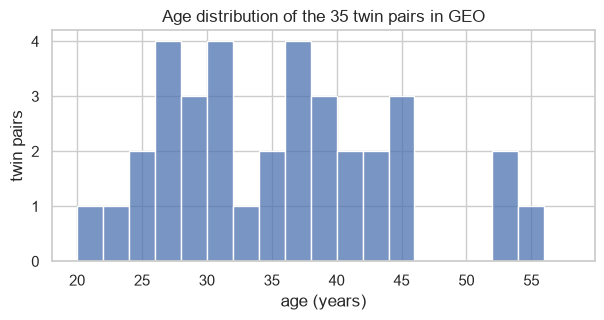

{'White': 31, 'Latino': 2, 'Af Am': 2}

In [5]:
pairs = s.groupby("pair").agg(age=("age", "mean"), race=("race", "first"))
fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(pairs["age"], bins=range(20, 60, 2), ax=ax)
ax.set(xlabel="age (years)", ylabel="twin pairs", title="Age distribution of the 35 twin pairs in GEO")
plt.show()
pairs["race"].value_counts().to_dict()

## 5. A first look at β-values

A methylation array has a signature shape. Most CpGs are either mostly unmethylated (β near 0, typically in CpG islands) or mostly methylated (β near 1, typically outside islands). The 27k array was designed around promoters and so is dominated by island probes, which gives the big left peak.

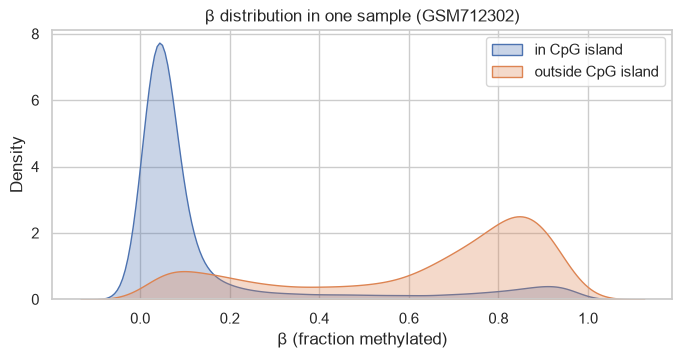

73% of 27k probes are in CpG islands
missing values: 2,823 of 2,316,552 (1198 probes have at least one NaN)


In [6]:
b = beta.loc[beta.index.intersection(probes.index)]
island = probes.loc[b.index, "CPG_ISLAND"]
sample_id = s.index[0]

fig, ax = plt.subplots(figsize=(8, 3.5))
for flag, label in [(True, "in CpG island"), (False, "outside CpG island")]:
    sns.kdeplot(b.loc[island == flag, sample_id].dropna(), ax=ax, label=label, fill=True, alpha=0.3)
ax.set(xlabel="β (fraction methylated)", title=f"β distribution in one sample ({sample_id})")
ax.legend()
plt.show()
print(f"{island.mean():.0%} of 27k probes are in CpG islands")
print(f"missing values: {beta.isna().sum().sum():,} of {beta.size:,} "
      f"({beta.isna().any(axis=1).sum()} probes have at least one NaN)")

## 6. Quality control: how similar are the arrays to each other?

A simple and powerful QC is to correlate every array with every other array across all CpGs. Two samples of human saliva should look very alike, with Pearson r well above 0.95, simply because most CpGs have similar β in everyone. An array that correlates poorly with *all* the others is suspicious: failed bisulfite conversion, degraded DNA, a scanner problem.

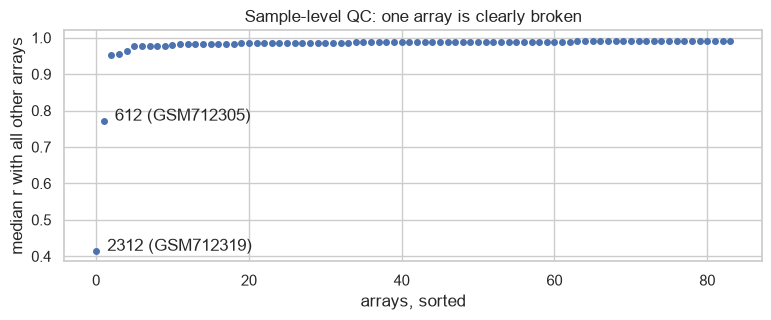

,title,pair,chip,median_r
geo_accession,,,,
GSM712319,2312,23,4671944009,0.414999
GSM712305,612,6,4671944009,0.772259
GSM712308,911,9,4671944018,0.953269
GSM712351,5111,51,4671944009,0.955328
GSM712315,2012,20,4671944018,0.964786


In [7]:
X = beta.dropna()  # probes without missing values
C = pd.DataFrame(np.corrcoef(X.T.values), index=X.columns, columns=X.columns)
median_r = C.where(~np.eye(len(C), dtype=bool)).median().sort_values()

qc = s[["title", "pair", "chip"]].assign(median_r=median_r).sort_values("median_r")
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(len(qc)), qc["median_r"], "o", ms=4)
for i, (gsm, row) in enumerate(qc.head(2).iterrows()):
    ax.annotate(f"{row.title} ({gsm})", (i, row.median_r), xytext=(8, 0), textcoords="offset points")
ax.set(xlabel="arrays, sorted", ylabel="median r with all other arrays",
       title="Sample-level QC: one array is clearly broken")
plt.show()
qc.head(5)

Array **`2312`** (GSM712319, pair 23) has a median correlation of about 0.41 with everything else. It is clearly broken. The paper says "one outlier sample was removed", and this is almost certainly the one.

Array `612` (GSM712305) is also low (~0.77) but far less extreme. The paper doesn't mention it. Let's see *how* these two arrays differ by plotting them against a good array from the same twin pair:

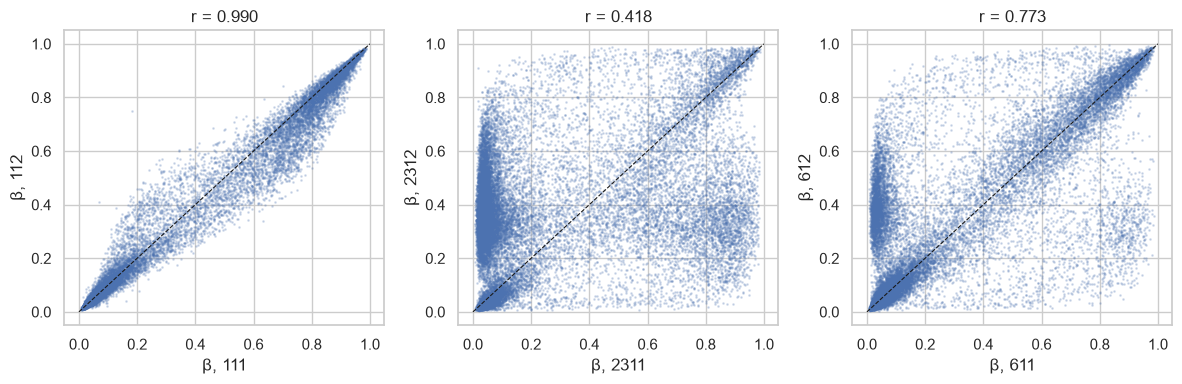

In [8]:
def compare(a_title, b_title, ax):
    a, b = s.index[s.title == a_title][0], s.index[s.title == b_title][0]
    ax.scatter(X[a], X[b], s=1, alpha=0.2)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set(xlabel=f"β, {a_title}", ylabel=f"β, {b_title}", title=f"r = {C.loc[a, b]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
compare("111", "112", axes[0])   # a typical twin pair
compare("2311", "2312", axes[1])  # the broken array vs its twin
compare("611", "612", axes[2])   # the second-weakest array vs its twin
plt.tight_layout()
plt.show()

A normal twin pair lies tightly on the diagonal. `2312` is almost uncorrelated with its twin, which is essentially noise, so we drop it. `612` has the right overall shape but is noisier. We **flag it** and will check in Part 2 whether removing it changes anything. Setting such rules before looking at the results that depend on them protects us from choosing whatever gives the nicest answer.

## 7. Reproducing the first numbers of the paper

The paper reports median correlations of:
- **0.995** between technical replicates (same DNA, two arrays);
- **0.992** between twins;
- **0.987** between unrelated people.

The ordering is what we'd expect: technical noise < twin differences < differences between unrelated people. Let's recompute these without the broken array.

,count,median,min,max,paper median
relationship,,,,,
technical replicate,15,0.9966,0.9885,0.9981,0.995
twin,56,0.9905,0.7729,0.9979,0.992
unrelated,3332,0.9871,0.7452,0.9958,0.987


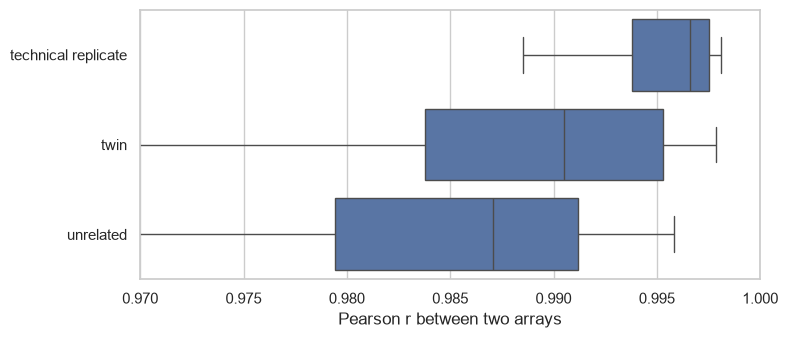

In [9]:
ok = s.index[s.title != "2312"]
rows = []
for i, a in enumerate(ok):
    for b_ in ok[i + 1:]:
        if s.person[a] == s.person[b_]:
            kind = "technical replicate"
        elif s.pair[a] == s.pair[b_]:
            kind = "twin"
        else:
            kind = "unrelated"
        rows.append((kind, C.loc[a, b_]))
pair_r = pd.DataFrame(rows, columns=["relationship", "r"])

summary = pair_r.groupby("relationship")["r"].agg(["count", "median", "min", "max"])
summary["paper median"] = pd.Series({"technical replicate": 0.995, "twin": 0.992, "unrelated": 0.987})
display(summary.round(4))

fig, ax = plt.subplots(figsize=(8, 3.5))
order = ["technical replicate", "twin", "unrelated"]
sns.boxplot(data=pair_r, y="relationship", x="r", order=order, ax=ax, fliersize=1)
ax.set(xlim=(0.97, 1.0), xlabel="Pearson r between two arrays", ylabel="")
plt.show()

Once the broken array is removed, we reproduce the paper's numbers almost exactly: 0.997 / 0.991 / 0.987 versus 0.995 / 0.992 / 0.987. This works even though we used all complete probes and no batch correction, which shows how robust whole-methylome correlations are. (Try including `2312` and watch the minimum values collapse.)

The paper also says these differences are "highly significant (Wilcoxon test)". Be careful with such p-values: the ~3,300 "unrelated" correlations are **not independent**. Each array appears in ~80 of them, so a single odd array shifts many values at once. The ordering is convincing; the p-value is not really meaningful.

Now the mysterious `4414`. How similar is it to the two members of pair 44?

In [10]:
g = {t: s.index[s.title == t][0] for t in ["4411", "4412", "4414"]}
pd.DataFrame({t: [C.loc[g[t], g[u]] for u in g] for t in g}, index=list(g)).round(4)

,4411,4412,4414
4411,1.0000,0.9979,0.9957
4412,0.9979,1.0000,0.9953
4414,0.9957,0.9953,1.0000


`4414` is about equally similar to both twins (r ≈ 0.995). That is higher than a typical twin pair (0.990) but lower than the twins of pair 44 are to each other (0.998). The data can't tell us whether it is a re-hybridization of twin 1, of twin 2, or something else. What matters is that it is **not a new independent person**. **We treat `4414` as a replicate** and leave it out of the association analyses.

In [11]:
s.loc[s.title == "4414", "is_replicate"] = True

## 8. What drives the variation between samples?

Before looking for age effects, we should know which *other* factors move the data. Two usual suspects:

- **Batch effects.** Samples are processed in batches: 12 per chip, and chips are hybridized and scanned on different days. Small technical differences between batches shift the measurements. They are dangerous when batch is **confounded** with the variable of interest. If, say, the older twins happened to be on chip A and the younger ones on chip B, any chip difference would look like an age effect.
- **Cell composition.** Saliva is a mixture of white blood cells and cheek epithelium, and each cell type has its own methylation profile. Someone with more leukocytes in their saliva will look "different" at thousands of CpGs at once.

**Principal component analysis (PCA)** finds the directions of largest variation across all CpGs. We then ask what each direction corresponds to.

We leave out the noisy array `612` as well as the broken `2312`. PCA is sensitive to outliers: with `612` included, the whole second component (~19% of the variance) describes that one array (see Exercise 5).

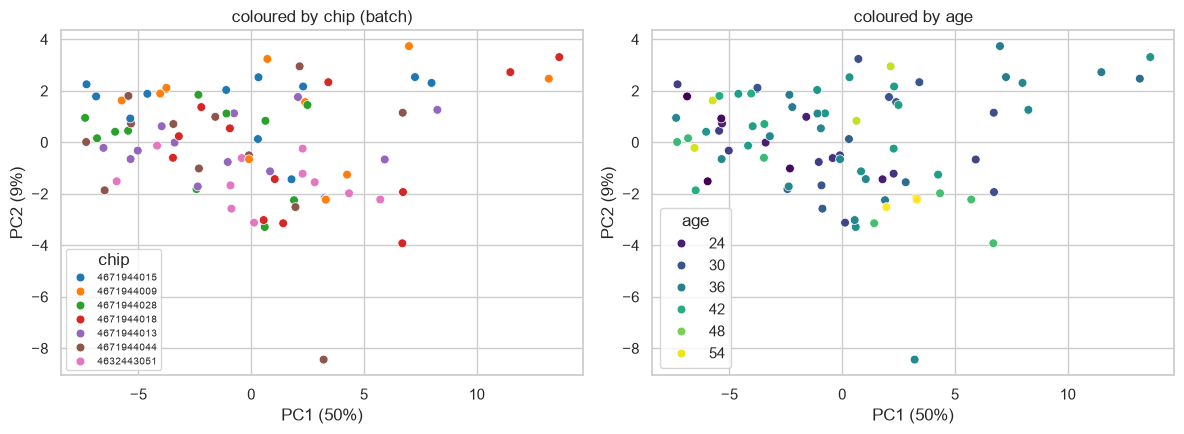

In [12]:
from sklearn.decomposition import PCA

good = s.index[~s.title.isin(["2312", "612"])]
Xg = X[good]
Xg = Xg[(Xg.mean(axis=1) > 0.05) & (Xg.mean(axis=1) < 0.95)]
pca = PCA(n_components=5).fit(Xg.T.values - Xg.T.values.mean(axis=0))
pcs = pd.DataFrame(pca.transform(Xg.T.values - Xg.T.values.mean(axis=0))[:, :2],
                   index=good, columns=["PC1", "PC2"]).join(s[["chip", "age"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=pcs, x="PC1", y="PC2", hue="chip", palette="tab10", ax=axes[0], s=40)
axes[0].legend(fontsize=7, title="chip")
sns.scatterplot(data=pcs, x="PC1", y="PC2", hue="age", palette="viridis", ax=axes[1], s=40)
ev = pca.explained_variance_ratio_
for ax in axes:
    ax.set(xlabel=f"PC1 ({ev[0]:.0%})", ylabel=f"PC2 ({ev[1]:.0%})")
axes[0].set_title("coloured by chip (batch)")
axes[1].set_title("coloured by age")
plt.tight_layout()
plt.show()

How much of each principal component is explained by chip, and how much by age? We use a one-way ANOVA *R²* for chip and a squared correlation for age:

In [13]:
scores = pd.DataFrame(pca.transform(Xg.T.values - Xg.T.values.mean(axis=0)), index=good,
                      columns=[f"PC{i + 1}" for i in range(5)])
res = {}
for pc in scores:
    y = scores[pc]
    chip_means = y.groupby(s.loc[good, "chip"]).transform("mean")
    res[pc] = {
        "variance explained": ev[int(pc[2:]) - 1],
        "R² chip": 1 - ((y - chip_means) ** 2).sum() / ((y - y.mean()) ** 2).sum(),
        "R² age": np.corrcoef(y, s.loc[good, "age"])[0, 1] ** 2,
    }
pd.DataFrame(res).T.round(3)

,variance explained,R² chip,R² age
PC1,0.504,0.133,0.006
PC2,0.092,0.199,0.007
PC3,0.071,0.895,0.027
PC4,0.019,0.067,0.000
PC5,0.016,0.332,0.001


Three observations:

1. **Age explains almost nothing** of the main axes (R² < 3%). Aging is a quiet signal spread over many CpGs.
2. **The chip dominates one component (PC3)** but not the first ones. There is a batch effect, but it is not the biggest source of variation.
3. **PC1 carries ~50% of all variance and is neither chip nor age.** What is it?

To find out, we look at the CpGs with the largest weights (*loadings*) on PC1, i.e. the CpGs that move most along this axis, and at the genes they sit in:

In [14]:
loadings = pd.Series(pca.components_[0], index=Xg.index)
top = pd.concat([loadings.nsmallest(15), loadings.nlargest(15)])
side = np.where(top > 0, "PC1 positive", "PC1 negative")
genes = pd.DataFrame({"side": side, "gene": probes["Symbol"].reindex(top.index).values})
for name, g in genes.groupby("side"):
    print(f"{name}: {', '.join(g['gene'].dropna())}")

PC1 negative: SLC6A6, UNQ467, MGC35048, HAS1, Gcom1, SERPINB5, CDH1, APOBEC2, SCGB2A1, C17orf73, LCE1B, SLC22A18AS, FRK, SDR-O, C1orf161
PC1 positive: FOXI1, CD6, TMC8, CD33, CXorf9, CST7, NKG7, RBP1, TRAF3IP3, C10orf27, TYROBP, CIAS1, PECAM1, LAT, BATF


The two ends of PC1 are two cell types:

- **positive side: immune genes.** *CD6, CD33, NKG7, CST7, TYROBP, NLRP3 (CIAS1), PECAM1, LAT, BATF, TRAF3IP3*: markers of leukocytes (T and NK cells, myeloid cells).
- **negative side: epithelial genes.** *CDH1* (E-cadherin), *SERPINB5* (maspin), *LCE1B* (late cornified envelope), *SCGB2A1*, *FRK*: markers of the epithelium lining the mouth.

So **PC1 is the leukocyte/epithelial ratio of each saliva sample**, the largest source of variation in the whole dataset. Fortunately it is not correlated with age here (R² < 1%). If it were, for example if older people had more leukocytes in their saliva, every leukocyte-specific CpG would appear "age-associated". This problem, **confounding by cell composition**, is one of the main themes of later chapters. The paper does not address it.

The authors corrected for chip using **ComBat** [(Johnson et al. 2007)](https://doi.org/10.1093/biostatistics/kxj037), an empirical-Bayes method that removes per-batch shifts in location and scale for every probe. We apply it in Part 2, where it is available in R's `sva` package.

Is chip confounded with age here? If twin pairs were split randomly across chips, we're fine:

In [15]:
per_chip = s.loc[good].groupby("chip").agg(arrays=("age", "size"), mean_age=("age", "mean"),
                                           min_age=("age", "min"), max_age=("age", "max"))
print("ANOVA of age by chip: p =",
      round(stats.f_oneway(*[g_["age"] for _, g_ in s.loc[good].groupby("chip")]).pvalue, 3))
per_chip

ANOVA of age by chip: p = 0.661


,arrays,mean_age,min_age,max_age
chip,,,,
4632443051,12,32.666667,21,45
4671944009,10,38.500000,29,55
4671944013,12,34.750000,24,53
4671944015,12,34.166667,21,55
4671944018,12,37.500000,29,45
4671944028,12,37.000000,27,52
4671944044,12,36.666667,22,55


Age is balanced across chips, so the batch effect adds noise but should not create false age associations. That is the benign case. Real-world studies are often not so lucky.

## 9. Probe filtering

The paper keeps probes with **mean β between 0.05 and 0.95 and variance > 0**, which leaves **16,155** probes. The logic: a CpG that is always ~0% or ~100% methylated carries almost no information about age, and near the edges of [0, 1] the array is also least precise.

The authors published per-probe statistics for exactly these 16,155 probes (Dataset S1). Let's download that file and compare it with our own filtering.

In [16]:
s1_path = download(
    "https://journals.plos.org/plosone/article/file?type=supplementary&id=10.1371/journal.pone.0014821.s001",
    DATA_DIR / "external" / "bocklandt2011" / "Dataset_S1.xls",
)
S1 = pd.read_excel(s1_path).set_index("TargetID")
S1.columns = ["chr", "position", "gene_id", "symbol", "module", "r", "p", "q"]

analysis = s.index[(s.title != "2312") & ~s.is_replicate]
m = beta[analysis].mean(axis=1)
v = beta[analysis].var(axis=1)
ours = beta.index[(m > 0.05) & (m < 0.95) & (v > 0)]

print(f"our filter:       {len(ours):,} probes")
print(f"paper (S1):       {len(S1):,} probes")
print(f"in both:          {len(ours.intersection(S1.index)):,}")
print(f"only ours:        {len(ours.difference(S1.index)):,}")
print(f"only paper:       {len(S1.index.difference(ours)):,}")

our filter:       19,018 probes
paper (S1):       16,155 probes
in both:          16,100
only ours:        2,918
only paper:       55


The two sets mostly agree: almost all of the paper's probes pass our filter, and the few that don't sit right at the 0.05/0.95 boundary, where small data differences flip them. But we keep ~2,900 extra probes, so the paper must have applied another step it doesn't describe. The usual candidates are detection p-values (is the signal above background?), removal of sex-chromosome probes, or probes with missing values. Let's check the extra probes:

In [17]:
extra = ours.difference(S1.index)
chrom = probes["Chr"].astype(str)
comparison = pd.DataFrame({
    "paper probes (S1)": [chrom.reindex(S1.index).isin(["X", "Y"]).mean(),
                          beta.loc[S1.index, analysis].isna().any(axis=1).mean(),
                          probes["CPG_ISLAND"].reindex(S1.index).mean()],
    "extra probes (ours only)": [chrom.reindex(extra).isin(["X", "Y"]).mean(),
                                 beta.loc[extra, analysis].isna().any(axis=1).mean(),
                                 probes["CPG_ISLAND"].reindex(extra).mean()],
}, index=["on X/Y chromosome", "has missing values", "in CpG island"])
comparison.style.format("{:.1%}")

,paper probes (S1),extra probes (ours only)
on X/Y chromosome,4.4%,7.2%
has missing values,0.0%,22.4%
in CpG island,64.2%,46.2%


The extra probes are much more likely to have missing values (a sign of weak signal), but that alone doesn't explain ~2,900 probes. We can't reverse-engineer the exact rule, so **for comparisons with the paper we use the paper's 16,155 probes**. This is a common, honest compromise when reproducing published work: when a step is undocumented, borrow the authors' output for that step and say so.

## 10. Save the analysis dataset

To summarize the decisions made in this notebook:

| Decision | Why |
|---|---|
| Drop array `2312` | Broken array (median r ≈ 0.41); this is the outlier the paper mentions |
| Flag array `612` | Noisy (median r ≈ 0.77) but plausible; we test sensitivity in Part 2 |
| Treat 14 arrays (13 × `R` + `4414`) as technical replicates | Kept for noise estimates, excluded from association analyses |
| Use the paper's 16,155 probes for comparisons | Their filter can't be reproduced exactly |
| Keep `chip` as the batch variable | Strong chip effect; age is balanced across chips |

We save the sample sheet (with these flags) and the β-matrix for the next parts. CSV is readable from both Python and R.

In [18]:
s["qc_pass"] = s.title != "2312"
s["qc_flag"] = np.where(s.title == "612", "noisy", "")

sample_sheet = s[["title", "pair", "person", "age", "race", "sexual_orientation", "chip",
                  "position", "is_replicate", "qc_pass", "qc_flag"]]
sample_sheet.to_csv(OUT / "samples.csv")

probe_sheet = probes[["Chr", "MapInfo", "Symbol", "Distance_to_TSS", "CPG_ISLAND"]].copy()
probe_sheet["in_paper_S1"] = probe_sheet.index.isin(S1.index)
probe_sheet.to_csv(OUT / "probes.csv")

beta.to_csv(OUT / "beta.csv.gz", float_format="%.5f")
print(f"saved to {OUT}")
print(sample_sheet["is_replicate"].value_counts().to_dict(), "| qc_pass:", sample_sheet["qc_pass"].sum())

saved to /Users/dima/clocks/data/processed/bocklandt2011
{False: 70, True: 14} | qc_pass: 83


## Summary

- The public dataset has **84 arrays / 35 twin pairs**. The paper describes 34 pairs and 10 replicates. Title codes let us reconstruct who is who: 70 primary samples, 14 technical replicates, and one broken array.
- Replicates are more alike than twins, and twins more alike than strangers (median r ≈ 0.997 / 0.991 / 0.987), which reproduces the paper's numbers.
- The largest source of variation (PC1, ~50%) is **cell composition**: the leukocyte/epithelial ratio of saliva. The **chip batch effect** is clear but smaller. Age is a quiet signal. Neither composition nor chip is correlated with age here, so they add noise rather than bias, but this is luck, not design.
- The paper's probe filter can't be reproduced exactly from its description.

In **Part 2** we look for CpGs whose methylation correlates with age and try to reproduce the paper's 88 age-associated sites and its network modules.

## Exercises

1. Our QC used Pearson correlation on β-values. Repeat it with Spearman correlation. Does the ranking of bad arrays change?
2. Compute the median absolute β difference between technical replicates for each probe. Which probes are the noisiest? Are they enriched near β = 0.5, in CpG islands, or in particular genes?
3. Our PCA showed a chip effect. Is there also a **position** effect (the letter A–L on the chip)? Hint: repeat the R² table with `position` instead of `chip`.
4. Imagine the older twin pairs had all been hybridized on the first three chips. What would happen to a per-probe correlation with age? Simulate it by adding a chip-specific offset to the β-values.
5. Put array `612` back into the PCA. What happens to PC2? Why is PCA so sensitive to a single sample, and what alternatives (e.g. robust PCA, or removing outliers first) would you consider?

## References

- Bocklandt S, et al. (2011). Epigenetic predictor of age. *PLoS ONE* 6: e14821. [doi:10.1371/journal.pone.0014821](https://doi.org/10.1371/journal.pone.0014821)
- Fraga MF, et al. (2005). Epigenetic differences arise during the lifetime of monozygotic twins. *PNAS* 102: 10604–10609. [doi:10.1073/pnas.0500398102](https://doi.org/10.1073/pnas.0500398102)
- Johnson WE, Li C, Rabinovic A (2007). Adjusting batch effects in microarray expression data using empirical Bayes methods. *Biostatistics* 8: 118–127. [doi:10.1093/biostatistics/kxj037](https://doi.org/10.1093/biostatistics/kxj037)